In [2]:
library('DiffBind')
library(ChIPseeker)
library(TxDb.Mmusculus.UCSC.mm10.knownGene)
txdb <- TxDb.Mmusculus.UCSC.mm10.knownGene
library(clusterProfiler)

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loa

In [3]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)


Attaching package: ‘dplyr’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.3.3”

Attachi

In [4]:
samples <- DataFrame(SampleID=c('BL1_1','BL1_2','BL1_3','EE1_1','EE1_2','EE1_3','LE1_1','LE1_2','LE1_3'))
samples$Condition <- c('BL','BL','BL','EE','EE','EE','LE','LE','LE')
samples$Replicate <- c(1,2,3,1,2,3,1,2,3)
samples$bamReads <- c('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_3_sorted.bam',
                      '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/EE1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/EE1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/EE1_3_sorted.bam',
                      '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/LE1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/LE1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/LE1_3_sorted.bam')
samples$Peaks <- c('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_1/BL1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_2/BL1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_3/BL1_3_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/EE1_1/EE1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/EE1_2/EE1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/EE1_3/EE1_3_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/LE1_1/LE1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/LE1_2/LE1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/LE1_3/LE1_3_peaks.xls')
samples$PeakCaller <- c('macs','macs','macs','macs','macs','macs','macs','macs','macs')
samples

DataFrame with 9 rows and 6 columns
     SampleID   Condition Replicate               bamReads
  <character> <character> <numeric>            <character>
1       BL1_1          BL         1 /syn1/liangzhen/jinh..
2       BL1_2          BL         2 /syn1/liangzhen/jinh..
3       BL1_3          BL         3 /syn1/liangzhen/jinh..
4       EE1_1          EE         1 /syn1/liangzhen/jinh..
5       EE1_2          EE         2 /syn1/liangzhen/jinh..
6       EE1_3          EE         3 /syn1/liangzhen/jinh..
7       LE1_1          LE         1 /syn1/liangzhen/jinh..
8       LE1_2          LE         2 /syn1/liangzhen/jinh..
9       LE1_3          LE         3 /syn1/liangzhen/jinh..
                   Peaks  PeakCaller
             <character> <character>
1 /syn1/liangzhen/jinh..        macs
2 /syn1/liangzhen/jinh..        macs
3 /syn1/liangzhen/jinh..        macs
4 /syn1/liangzhen/jinh..        macs
5 /syn1/liangzhen/jinh..        macs
6 /syn1/liangzhen/jinh..        macs
7 /syn1/liangzhen/j

In [5]:
atac <- dba(sampleSheet=samples)

BL1_1   BL  1 macs

BL1_2   BL  2 macs

BL1_3   BL  3 macs

EE1_1   EE  1 macs

EE1_2   EE  2 macs

EE1_3   EE  3 macs

LE1_1   LE  1 macs

LE1_2   LE  2 macs

LE1_3   LE  3 macs



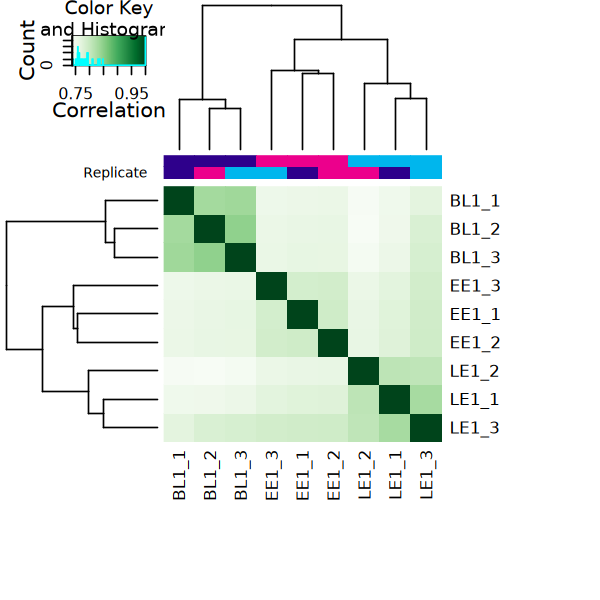

In [6]:
options(repr.plot.width=5, repr.plot.height=5)
plot(atac)

In [7]:
atac <- dba.count(atac, bUseSummarizeOverlaps=TRUE)

Computing summits...

Re-centering peaks...



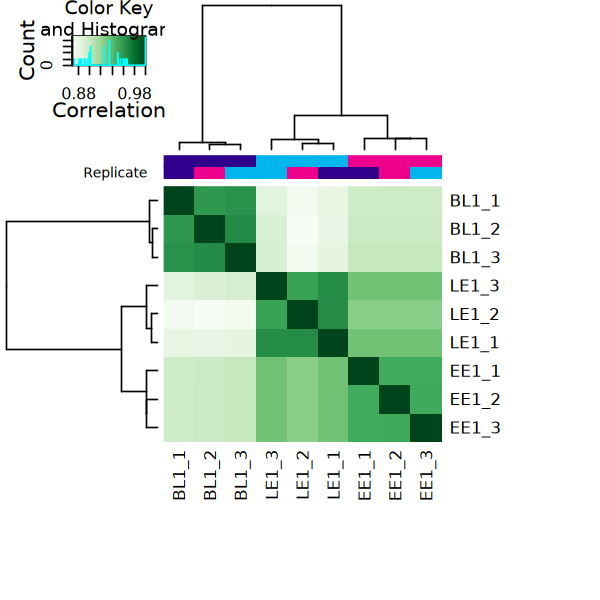

In [8]:
options(repr.plot.width=5, repr.plot.height=5)
plot(atac)

In [9]:
atac <- dba.normalize(atac)

In [10]:
norm_matrix <- dba.peakset(atac, bRetrieve = TRUE, DataType = DBA_DATA_FRAME)

In [11]:
norm_matrix$START <- as.character(norm_matrix$START)
norm_matrix$END <- as.character(norm_matrix$END)
norm_matrix

,CHR,START,END,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1,3493608,3494008,28.602162,26.404927,33.790047,53.462681,62.619518,64.34270,33.340408,20.522638,25.54199
2,chr1,3514774,3515174,452.134178,454.541953,465.262950,411.430201,449.932834,430.51117,482.153595,427.244003,478.67579
3,chr1,3516966,3517366,84.706403,90.531177,88.373968,60.436075,68.417622,47.96456,50.438053,35.448192,49.19198
4,chr1,3611159,3611559,52.803992,45.265589,32.923635,52.300449,48.704070,54.98376,44.453878,62.500760,52.97598
5,chr1,4768333,4768733,31.902412,36.778291,36.389281,23.244644,26.671276,29.24668,30.775761,37.313887,31.21799
6,chr1,4769812,4770212,34.102578,28.290993,21.660286,26.731341,19.713552,29.24668,29.920879,28.918262,20.81199
7,chr1,4780078,4780478,30.802328,47.151655,50.251864,38.353663,39.427104,35.09602,49.583171,42.910970,35.00198
8,chr1,4785445,4785845,326.724698,315.916088,347.430993,324.262786,248.158831,233.97346,306.047849,239.741722,340.55985
9,chr1,4807589,4807989,332.225114,396.073901,343.098935,290.558052,266.712763,317.03404,292.369733,242.540264,270.55588


In [12]:
norm_matrix$peak <- paste0(norm_matrix$CHR,'_',norm_matrix$START,'_',norm_matrix$END)
norm_matrix

,CHR,START,END,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3,peak
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,chr1,3493608,3494008,28.602162,26.404927,33.790047,53.462681,62.619518,64.34270,33.340408,20.522638,25.54199,chr1_3493608_3494008
2,chr1,3514774,3515174,452.134178,454.541953,465.262950,411.430201,449.932834,430.51117,482.153595,427.244003,478.67579,chr1_3514774_3515174
3,chr1,3516966,3517366,84.706403,90.531177,88.373968,60.436075,68.417622,47.96456,50.438053,35.448192,49.19198,chr1_3516966_3517366
4,chr1,3611159,3611559,52.803992,45.265589,32.923635,52.300449,48.704070,54.98376,44.453878,62.500760,52.97598,chr1_3611159_3611559
5,chr1,4768333,4768733,31.902412,36.778291,36.389281,23.244644,26.671276,29.24668,30.775761,37.313887,31.21799,chr1_4768333_4768733
6,chr1,4769812,4770212,34.102578,28.290993,21.660286,26.731341,19.713552,29.24668,29.920879,28.918262,20.81199,chr1_4769812_4770212
7,chr1,4780078,4780478,30.802328,47.151655,50.251864,38.353663,39.427104,35.09602,49.583171,42.910970,35.00198,chr1_4780078_4780478
8,chr1,4785445,4785845,326.724698,315.916088,347.430993,324.262786,248.158831,233.97346,306.047849,239.741722,340.55985,chr1_4785445_4785845
9,chr1,4807589,4807989,332.225114,396.073901,343.098935,290.558052,266.712763,317.03404,292.369733,242.540264,270.55588,chr1_4807589_4807989


In [14]:
write.table(norm_matrix,file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/norm_matrix.tsv',sep='\t',row.names = F,col.names = T,quote = F)

In [291]:
peak_gr <- makeGRangesFromDataFrame(as.data.frame(norm_matrix),keep.extra.columns = TRUE)
peak_gr

GRanges object with 95930 ranges and 10 metadata columns:
          seqnames            ranges strand |     BL1_1     BL1_2     BL1_3
             <Rle>         <IRanges>  <Rle> | <numeric> <numeric> <numeric>
      [1]     chr1   3493608-3494008      * |   28.6022   26.4049   33.7900
      [2]     chr1   3514774-3515174      * |  452.1342  454.5420  465.2630
      [3]     chr1   3516966-3517366      * |   84.7064   90.5312   88.3740
      [4]     chr1   3611159-3611559      * |   52.8040   45.2656   32.9236
      [5]     chr1   4768333-4768733      * |   31.9024   36.7783   36.3893
      ...      ...               ...    ... .       ...       ...       ...
  [95926]     chrY 90732208-90732608      * |   1.10008  3.772132   9.53053
  [95927]     chrY 90740158-90740558      * |  47.30358 38.664357  35.52287
  [95928]     chrY 90801397-90801797      * |   2.20017  0.943033   4.33206
  [95929]     chrY 90808651-90809051      * |  13.20100  9.430331   6.93129
  [95930]     chrY 90810591-90

In [313]:
peak_anno <- annotatePeak(peak_gr, 
                             tssRegion = c(-1000, 1000),  
                             TxDb=txdb, annoDb="org.Mm.eg.db")

>> preparing features information...		 2026-03-11 02:47:39 PM 
>> identifying nearest features...		 2026-03-11 02:47:39 PM 
>> calculating distance from peak to TSS...	 2026-03-11 02:47:41 PM 
>> assigning genomic annotation...		 2026-03-11 02:47:41 PM 
>> adding gene annotation...			 2026-03-11 02:47:43 PM 


'select()' returned 1:many mapping between keys and columns



>> assigning chromosome lengths			 2026-03-11 02:47:44 PM 
>> done...					 2026-03-11 02:47:44 PM 


In [159]:
eRegulon_direct <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/scATAC_and_scRNA/scenicplus/scplus_pipeline/Snakemake/eRegulon_direct.tsv',header=T)
eRegulon_direct <- eRegulon_direct[eRegulon_direct$eRegulon_name %in% c('Jun_direct_+/+','Fosb_direct_+/+'),]
eRegulon_direct <- eRegulon_direct[order(eRegulon_direct$triplet_rank,decreasing = T),]
eRegulon_direct$CHR <- as.character(as.data.frame(strsplit(eRegulon_direct$Region,split = ':'))[1,])
eRegulon_direct$START <- as.character(as.data.frame(strsplit(as.character(as.data.frame(strsplit(eRegulon_direct$Region,split = ':'))[2,]),split = '-'))[1,])
eRegulon_direct$END <- as.character(as.data.frame(strsplit(as.character(as.data.frame(strsplit(eRegulon_direct$Region,split = ':'))[2,]),split = '-'))[2,])
eRegulon_direct$peak <- paste0(eRegulon_direct$CHR,'_',eRegulon_direct$START,'_',eRegulon_direct$END)
eRegulon_direct

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank,CHR,START,END,peak
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
295,chr11:116016384-116016884,Mrpl38,0.0001425319,0.30134939,4.295190e-05,4.295190e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5921,chr11,116016384,116016884,chr11_116016384_116016884
527,chr11:116057522-116058022,Mrpl38,0.0004452865,0.18512820,8.243509e-05,8.243509e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5919,chr11,116057522,116058022,chr11_116057522_116058022
364,chr11:116079449-116079949,Mrpl38,0.0018699174,0.16440062,3.074156e-04,3.074156e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5917,chr11,116079449,116079949,chr11_116079449_116079949
433,chr11:116111500-116112000,Mrpl38,0.0009953956,0.07939124,7.902569e-05,7.902569e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5916,chr11,116111500,116112000,chr11_116111500_116112000
430,chr11:115884786-115885286,Mrpl38,0.0004542051,0.10129292,4.600776e-05,4.600776e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5915,chr11,115884786,115885286,chr11_115884786_115885286
535,chr11:115964870-115965370,Mrpl38,0.0011015092,0.12694138,1.398271e-04,1.398271e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5914,chr11,115964870,115965370,chr11_115964870_115965370
395,chr11:116078221-116078721,Mrpl38,0.0013907804,0.19597397,2.725568e-04,2.725568e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5912,chr11,116078221,116078721,chr11_116078221_116078721
938,chr18:61335824-61336324,Slc26a2,0.0112736349,0.09706908,1.094321e-03,1.094321e-03,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.3590801,1,0.07438589,5911,chr18,61335824,61336324,chr18_61335824_61336324
305,chrX:7722647-7723147,Tfe3,0.0097375508,0.06531212,6.359801e-04,6.359801e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.5616995,1,0.05323432,5910,chrX,7722647,7723147,chrX_7722647_7723147


In [275]:
selected_genes <- c('Lamc1','Nfkbiz','Col4a5','Col6a2','Runx2','Vcam1','Hes1','Thra','Notch2','Shc1','Pxdn','Col6a3','Mmp11','Rhob','Sparc','Fos','Col6a1','Runx1','Sox4','Nfix','Tcf4','Klf4','Arhgef3','Fn1','Col3a1','Nedd9','Cemip2','Ptk2b','Ereg','Arhgap5','Cxcl2','Bcr','Itgav','Itgb5')
selected_genes <- selected_genes[!selected_genes %in% c('Fn1','Ereg','Runx1','Cxcl2','Lamc1','Mmp11','Vcam1','Hes1','Col4a5','Rhob')]
selected_genes

[1] "Fosb"    "Jun"     "Col6a2"  "Nfkbiz"  "Col6a2"  "Runx2"   "Thra"   
 [8] "Notch2"  "Shc1"    "Pxdn"    "Col6a3"  "Sparc"   "Fos"     "Col6a1" 
[15] "Sox4"    "Nfix"    "Tcf4"    "Klf4"    "Arhgef3" "Col3a1"  "Nedd9"  
[22] "Cemip2"  "Ptk2b"   "Arhgap5" "Bcr"     "Itgav"   "Itgb5"

In [278]:
multiome_bed <- makeGRangesFromDataFrame(eRegulon_direct[eRegulon_direct$Gene %in% selected_genes,], 
                                 seqnames.field = "CHR",
                                 start.field = "START",
                                 end.field = "END",
                                 keep.extra.columns = TRUE)

bulk_bed <- makeGRangesFromDataFrame(norm_matrix,
                                   seqnames.field = "CHR",
                                 start.field = "START",
                                 end.field = "END",
                                 keep.extra.columns = TRUE)

In [279]:
overlaps <- findOverlaps(multiome_bed,bulk_bed)
overlaps

Hits object with 57 hits and 0 metadata columns:
       queryHits subjectHits
       <integer>   <integer>
   [1]         1       23307
   [2]         2       23297
   [3]         3       36427
   [4]         4       59662
   [5]         5       44122
   ...       ...         ...
  [53]        72       22708
  [54]        73         944
  [55]        74       20768
  [56]        75         944
  [57]        76       20768
  -------
  queryLength: 77 / subjectLength: 95930

In [248]:
bulk_bed[subjectHits(overlaps), ]

GRanges object with 57 ranges and 10 metadata columns:
       seqnames            ranges strand |     BL1_1     BL1_2     BL1_3
          <Rle>         <IRanges>  <Rle> | <numeric> <numeric> <numeric>
   [1]    chr13 41532620-41533020      * |  152.9116  160.3156  151.6220
   [2]    chr13 41431770-41432170      * |   73.7056   58.4681   60.6488
   [3]    chr16 55801617-55802017      * |   15.4012   17.9176   10.3969
   [4]     chr3 98043074-98043474      * |  288.2218  240.4734  269.4540
   [5]    chr18 69822783-69823183      * |   25.3019   20.7467   28.5916
   ...      ...               ...    ... .       ...       ...       ...
  [53]    chr13 29218576-29218976      * |  63.80482  42.43649  71.04574
  [54]     chr1 45355951-45356351      * |   7.70058   9.43033   5.19847
  [55]    chr12 85619484-85619884      * |  29.70225  15.08853  20.79387
  [56]     chr1 45355951-45356351      * |   7.70058   9.43033   5.19847
  [57]    chr12 85619484-85619884      * |  29.70225  15.08853  20.79

In [249]:
merged_df <- data.frame(
  multiome_bed[queryHits(overlaps), ],
  bulk_bed[subjectHits(overlaps), ]
)
merged_df

seqnames,start,end,width,strand,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,⋯,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3,peak.1
<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr13,41532591,41533091,501,*,chr13:41532591-41533091,Nedd9,0.018773280,0.14847779,0.0027874151,⋯,152.911559,160.315627,151.622004,181.308224,173.94311,197.70757,195.76804,192.16652,196.767912,chr13_41532620_41533020
chr13,41431676,41432176,501,*,chr13:41431676-41432176,Nedd9,0.018800986,0.11975109,0.0022514384,⋯,73.705572,58.468052,60.648802,54.624914,63.77914,90.07978,76.93940,58.76937,77.571965,chr13_41431770_41432170
chr16,55801633,55802133,501,*,chr16:55801633-55802133,Nfkbiz,0.021070537,0.30256825,0.0063752757,⋯,15.401164,17.917629,10.396937,31.380270,13.91545,17.54801,11.11347,19.58979,12.297995,chr16_55801617_55802017
chr3,98043040,98043540,501,*,chr3:98043040-98043540,Notch2,0.010162153,0.08588991,0.0008728264,⋯,288.221787,240.473440,269.453962,391.672254,346.72659,339.26152,410.34348,357.28047,384.075829,chr3_98043074_98043474
chr18,69822738,69823238,501,*,chr18:69822738-69823238,Tcf4,0.012616849,0.08410623,0.0010611556,⋯,25.301913,20.746728,28.591578,58.111610,83.49269,59.66323,58.98688,49.44090,53.921976,chr18_69822783_69823183
chr13,41469486,41469986,501,*,chr13:41469486-41469986,Nedd9,0.020324774,0.09424015,0.0019154097,⋯,149.611310,130.138568,119.564781,188.281617,140.31411,191.85824,145.32998,134.32999,152.305932,chr13_41469544_41469944
chr3,98106617,98107117,501,*,chr3:98106617-98107117,Notch2,0.030178812,0.30691477,0.0092623232,⋯,68.205156,66.955350,54.583922,342.858501,360.64204,350.96019,393.24584,348.88484,408.671818,chr3_98106654_98107054
chr14,27198779,27199279,501,*,chr14:27198779-27199279,Arhgef3,0.030307660,0.05539891,0.0016790113,⋯,62.704740,69.784449,51.984687,67.409468,71.89648,60.83310,52.14782,31.71680,64.327971,chr14_27198808_27199208
chr13,41705624,41706124,501,*,chr13:41705624-41706124,Nedd9,0.016790695,0.14872342,0.0024971695,⋯,310.223451,275.365665,285.049368,252.204389,311.93797,272.57908,282.11115,273.32422,289.475871,chr13_41705625_41706025


In [250]:
test <- merged_df[,c(7,27:35)]
test

Gene,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Nedd9,152.911559,160.315627,151.622004,181.308224,173.94311,197.70757,195.76804,192.16652,196.767912
Nedd9,73.705572,58.468052,60.648802,54.624914,63.77914,90.07978,76.93940,58.76937,77.571965
Nfkbiz,15.401164,17.917629,10.396937,31.380270,13.91545,17.54801,11.11347,19.58979,12.297995
Notch2,288.221787,240.473440,269.453962,391.672254,346.72659,339.26152,410.34348,357.28047,384.075829
Tcf4,25.301913,20.746728,28.591578,58.111610,83.49269,59.66323,58.98688,49.44090,53.921976
Nedd9,149.611310,130.138568,119.564781,188.281617,140.31411,191.85824,145.32998,134.32999,152.305932
Notch2,68.205156,66.955350,54.583922,342.858501,360.64204,350.96019,393.24584,348.88484,408.671818
Arhgef3,62.704740,69.784449,51.984687,67.409468,71.89648,60.83310,52.14782,31.71680,64.327971
Nedd9,310.223451,275.365665,285.049368,252.204389,311.93797,272.57908,282.11115,273.32422,289.475871


In [251]:
test <- test %>%
  group_by(Gene) %>%
  summarise(across(everything(), mean, na.rm = TRUE))
test

Gene,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Arhgap5,94.607152,108.448806,82.309088,183.632689,149.59107,149.74301,122.24816,121.27013,141.899937
Arhgef3,73.430551,69.312933,63.464639,89.782438,93.34947,85.69278,72.23755,64.59967,69.767469
Col3a1,7.700582,9.430331,5.198469,22.082412,26.67128,17.54801,32.48553,33.58250,38.785983
Col6a1,165.012474,148.056196,152.488416,205.133984,198.29514,211.74598,197.05036,181.90520,201.024910
Col6a3,50.603825,59.411085,61.515213,76.707326,93.92928,79.55098,101.73099,77.42631,101.221955
Fos,109.348266,114.295611,106.915173,137.143400,136.60332,131.02514,187.39019,177.42753,198.092312
Itgb5,367.427775,347.036180,366.492045,356.805287,324.69380,368.50820,451.37783,451.49803,458.809796
Klf4,14.301081,15.088530,17.328229,30.218037,18.55393,37.43575,26.50135,27.05257,33.109985
Nedd9,142.766348,139.883243,131.598273,140.500960,158.22380,158.58201,153.40387,141.58547,160.609706


In [252]:
test[,2:10]

BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
94.607152,108.448806,82.309088,183.632689,149.59107,149.74301,122.24816,121.27013,141.899937
73.430551,69.312933,63.464639,89.782438,93.34947,85.69278,72.23755,64.59967,69.767469
7.700582,9.430331,5.198469,22.082412,26.67128,17.54801,32.48553,33.58250,38.785983
165.012474,148.056196,152.488416,205.133984,198.29514,211.74598,197.05036,181.90520,201.024910
50.603825,59.411085,61.515213,76.707326,93.92928,79.55098,101.73099,77.42631,101.221955
109.348266,114.295611,106.915173,137.143400,136.60332,131.02514,187.39019,177.42753,198.092312
367.427775,347.036180,366.492045,356.805287,324.69380,368.50820,451.37783,451.49803,458.809796
14.301081,15.088530,17.328229,30.218037,18.55393,37.43575,26.50135,27.05257,33.109985
142.766348,139.883243,131.598273,140.500960,158.22380,158.58201,153.40387,141.58547,160.609706


In [148]:
library(ComplexHeatmap)
library(RColorBrewer)

In [253]:
df <- test[,2:10]
df <- t(scale(t(df)))
rownames(df) <- test$Gene
df

,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3
Arhgap5,-1.069490890,-0.62874322,-1.4610873,1.76527120,0.6813138,0.68615203,-0.18934240,-0.22048500,0.4364118
Arhgef3,-0.208892152,-0.58173885,-1.1112967,1.27175684,1.5947482,0.90144189,-0.31691724,-1.00852097,-0.5405810
Col3a1,-1.121910999,-0.98126323,-1.3253606,0.04749129,0.4206169,-0.32120592,0.89337985,0.98257585,1.4056769
Col6a1,-0.820080714,-1.53277639,-1.3464841,0.86628160,0.5788356,1.14419293,0.52651578,-0.11005627,0.6935716
Col6a3,-1.484057438,-1.00715357,-0.8932173,-0.07058033,0.8619702,0.08340037,1.28442473,-0.03164782,1.2568611
Fos,-1.004676714,-0.86225897,-1.0747174,-0.20454657,-0.2200937,-0.38067115,1.24189264,0.95510055,1.5499713
Itgb5,-0.403058066,-0.80118175,-0.4213272,-0.61045057,-1.2373924,-0.38196395,1.23597543,1.23832213,1.3810764
Klf4,-1.202651886,-1.10886598,-0.8421155,0.69307345,-0.6961332,1.55271064,0.25041230,0.31606289,1.0375073
Nedd9,-0.452376549,-0.73016162,-1.5284125,-0.67064501,1.0369382,1.07145129,0.57254128,-0.56615324,1.2668182
Nfix,-1.426477759,-1.23798506,-1.0274757,0.72256785,1.1323211,0.18276638,-0.02221877,1.09648154,0.5800204


png 
  2

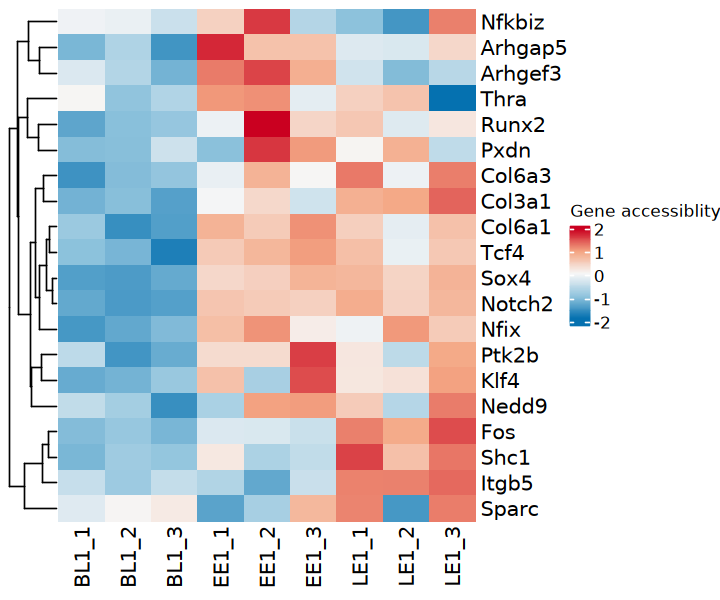

In [258]:
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure3/bulk_selected_gene_accessiblity.pdf',width=6,height=5)
options(repr.plot.width=6, repr.plot.height=5)
plot <- Heatmap(df,col = colorRampPalette(rev(brewer.pal(n = 5, name = "RdBu")))(100),
                cluster_rows = T,cluster_columns = F,
                show_row_names = T,show_column_names = T,
                name = "Gene accessiblity")
print(plot)
dev.off()
print(plot)

In [331]:
eRegulon_direct <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/scATAC_and_scRNA/scenicplus/scplus_pipeline/Snakemake/eRegulon_direct.tsv',header=T)
eRegulon_direct <- eRegulon_direct[eRegulon_direct$eRegulon_name %in% c('Jun_direct_+/+','Fosb_direct_+/+'),]
eRegulon_direct <- eRegulon_direct[order(eRegulon_direct$triplet_rank,decreasing = T),]
eRegulon_direct$CHR <- as.character(as.data.frame(strsplit(eRegulon_direct$Region,split = ':'))[1,])
eRegulon_direct$START <- as.character(as.data.frame(strsplit(as.character(as.data.frame(strsplit(eRegulon_direct$Region,split = ':'))[2,]),split = '-'))[1,])
eRegulon_direct$END <- as.character(as.data.frame(strsplit(as.character(as.data.frame(strsplit(eRegulon_direct$Region,split = ':'))[2,]),split = '-'))[2,])
eRegulon_direct$peak <- paste0(eRegulon_direct$CHR,'_',eRegulon_direct$START,'_',eRegulon_direct$END)
eRegulon_direct

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank,CHR,START,END,peak
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
295,chr11:116016384-116016884,Mrpl38,0.0001425319,0.30134939,4.295190e-05,4.295190e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5921,chr11,116016384,116016884,chr11_116016384_116016884
527,chr11:116057522-116058022,Mrpl38,0.0004452865,0.18512820,8.243509e-05,8.243509e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5919,chr11,116057522,116058022,chr11_116057522_116058022
364,chr11:116079449-116079949,Mrpl38,0.0018699174,0.16440062,3.074156e-04,3.074156e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5917,chr11,116079449,116079949,chr11_116079449_116079949
433,chr11:116111500-116112000,Mrpl38,0.0009953956,0.07939124,7.902569e-05,7.902569e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5916,chr11,116111500,116112000,chr11_116111500_116112000
430,chr11:115884786-115885286,Mrpl38,0.0004542051,0.10129292,4.600776e-05,4.600776e-05,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5915,chr11,115884786,115885286,chr11_115884786_115885286
535,chr11:115964870-115965370,Mrpl38,0.0011015092,0.12694138,1.398271e-04,1.398271e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5914,chr11,115964870,115965370,chr11_115964870_115965370
395,chr11:116078221-116078721,Mrpl38,0.0013907804,0.19597397,2.725568e-04,2.725568e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.4514274,1,0.07658214,5912,chr11,116078221,116078721,chr11_116078221_116078721
938,chr18:61335824-61336324,Slc26a2,0.0112736349,0.09706908,1.094321e-03,1.094321e-03,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.3590801,1,0.07438589,5911,chr18,61335824,61336324,chr18_61335824_61336324
305,chrX:7722647-7723147,Tfe3,0.0097375508,0.06531212,6.359801e-04,6.359801e-04,Jun,False,Jun_direct_+/+,Jun_direct_+/+_(184g),Jun_direct_+/+_(620r),0.5616995,1,0.05323432,5910,chrX,7722647,7723147,chrX_7722647_7723147


In [332]:
multiome_bed <- makeGRangesFromDataFrame(eRegulon_direct, 
                                 seqnames.field = "CHR",
                                 start.field = "START",
                                 end.field = "END",
                                 keep.extra.columns = TRUE)

bulk_bed <- makeGRangesFromDataFrame(norm_matrix,
                                   seqnames.field = "CHR",
                                 start.field = "START",
                                 end.field = "END",
                                 keep.extra.columns = TRUE)

In [333]:
overlaps <- findOverlaps(multiome_bed,bulk_bed)
overlaps

Hits object with 516 hits and 0 metadata columns:
        queryHits subjectHits
        <integer>   <integer>
    [1]         3       17630
    [2]         6       17609
    [3]         8       43619
    [4]        12       17635
    [5]        13       17630
    ...       ...         ...
  [512]       779       20768
  [513]       780       38922
  [514]       781         944
  [515]       782       20768
  [516]       784       84979
  -------
  queryLength: 784 / subjectLength: 95930

In [334]:
merged_df <- data.frame(
  multiome_bed[queryHits(overlaps), ],
  bulk_bed[subjectHits(overlaps), ]
)
merged_df

seqnames,start,end,width,strand,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,⋯,BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3,peak.1
<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr11,116079449,116079949,501,*,chr11:116079449-116079949,Mrpl38,0.0018699174,0.16440062,3.074156e-04,⋯,178.21347,168.802925,173.28229,299.85591,270.19162,304.16550,281.25626,249.07019,296.09787,chr11_116079151_116079551
chr11,115964870,115965370,501,*,chr11:115964870-115965370,Mrpl38,0.0011015092,0.12694138,1.398271e-04,⋯,624.84723,599.769050,661.07194,861.21406,796.65943,913.66636,879.67385,769.59891,883.56361,chr11_115964933_115965333
chr18,61335824,61336324,501,*,chr18:61335824-61336324,Slc26a2,0.0112736349,0.09706908,1.094321e-03,⋯,13.20100,5.658199,11.26335,29.05581,22.03279,23.39735,29.06600,36.38104,26.48799,chr18_61335839_61336239
chr11,116103512,116104012,501,*,chr11:116103512-116104012,Mrpl38,0.0008192221,0.10314787,8.450101e-05,⋯,563.24258,558.275594,544.97280,805.42692,812.89412,835.28525,1072.02235,923.51870,1068.97952,chr11_116103728_116104128
chr11,116079449,116079949,501,*,chr11:116079449-116079949,Unk,0.0017510115,0.10633794,1.861990e-04,⋯,178.21347,168.802925,173.28229,299.85591,270.19162,304.16550,281.25626,249.07019,296.09787,chr11_116079151_116079551
chr10,13869497,13869997,501,*,chr10:13869497-13869997,Hivep2,0.0106941070,0.05760287,6.160113e-04,⋯,134.21015,135.796766,134.29378,80.19402,114.80245,101.77846,88.90776,77.42631,100.27596,chr10_13869104_13869504
chr11,115970256,115970756,501,*,chr11:115970256-115970756,Mrpl38,0.0004937051,0.23540804,1.162221e-04,⋯,389.42944,410.219398,373.42334,734.53075,724.76294,708.93958,860.86644,814.37558,910.99759,chr11_115970302_115970702
chr17,24667369,24667869,501,*,chr17:24667369-24667869,Pkd1,0.0018396302,0.09018964,1.659156e-04,⋯,353.12669,393.244802,364.75922,285.90912,235.40300,279.59828,277.83673,217.35339,245.01389,chr17_24667409_24667809
chr11,115964870,115965370,501,*,chr11:115964870-115965370,H3f3b,0.0020436051,0.26594606,5.434887e-04,⋯,624.84723,599.769050,661.07194,861.21406,796.65943,913.66636,879.67385,769.59891,883.56361,chr11_115964933_115965333


In [273]:
df <- merged_df[,27:35]
df <- as.data.frame(t(scale(t(df))))
df

BL1_1,BL1_2,BL1_3,EE1_1,EE1_2,EE1_3,LE1_1,LE1_2,LE1_3
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-1.19189213,-1.35549795,-1.2776225,0.92290637,0.40718188,0.99783016,0.5995447,0.03997804,0.8575714
-1.26026293,-1.46842873,-0.9595735,0.70174089,0.16589393,1.13713026,0.8549695,-0.05872654,0.8872571
-0.87019166,-1.63012584,-1.0654091,0.72717419,0.01960841,0.15708657,0.7282010,1.46518879,0.4684676
-1.13591475,-1.15991863,-1.2242068,0.03448629,0.07057291,0.17878225,1.3228585,0.60518684,1.3081534
-1.19189213,-1.35549795,-1.2776225,0.92290637,0.40718188,0.99783016,0.5995447,0.03997804,0.8575714
1.14246694,1.21038356,1.1460468,-1.16973792,0.31170448,-0.24579840,-0.7967394,-1.28821192,-0.3101141
-1.27422378,-1.17581230,-1.3499904,0.35935001,0.31311303,0.23821148,0.9573734,0.73730397,1.1946746
0.94495502,1.59373131,1.1330723,-0.14206448,-0.95883212,-0.24412119,-0.2726084,-1.25072428,-0.8034081
-1.26026293,-1.46842873,-0.9595735,0.70174089,0.16589393,1.13713026,0.8549695,-0.05872654,0.8872571


png 
  2

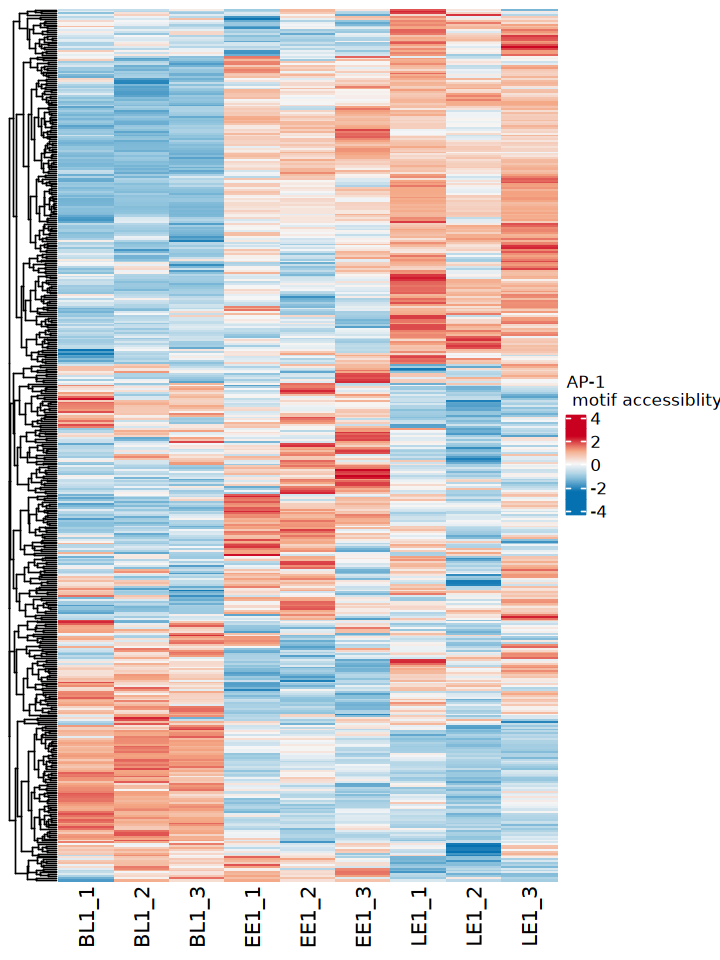

In [170]:
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure3/AP-1_motif_accessibility_heatmap.pdf',width=6,height=8)
options(repr.plot.width=6, repr.plot.height=8)
plot <- Heatmap(as.matrix(df),col = colorRampPalette(rev(brewer.pal(n = 5, name = "RdBu")))(100),
                cluster_rows = T,cluster_columns = F,
                show_row_names = F,show_column_names = T,
                name = "AP-1 \n motif accessiblity")
print(plot)
dev.off()
print(plot)

In [35]:
library(tidyr)

In [160]:
df.longer <- pivot_longer(data = df,cols = -c('peaks'),names_to = 'sample',values_to = 'accessbility' )
df.longer$time <- substr(df.longer$sample,1,2)
df.longer

peaks,sample,accessbility,time
<chr>,<chr>,<dbl>,<chr>
chr1_24186920_24187320,BL1_1,1.09023004,BL
chr1_24186920_24187320,BL1_2,-0.35018327,BL
chr1_24186920_24187320,BL1_3,0.69941103,BL
chr1_24186920_24187320,EE1_1,-1.16407798,EE
chr1_24186920_24187320,EE1_2,-1.41436409,EE
chr1_24186920_24187320,EE1_3,1.52804326,EE
chr1_24186920_24187320,LE1_1,0.02338924,LE
chr1_24186920_24187320,LE1_2,-0.66642570,LE
chr1_24186920_24187320,LE1_3,0.25397747,LE


In [161]:
library(ggplot2)
library(ggpubr)

png 
  2

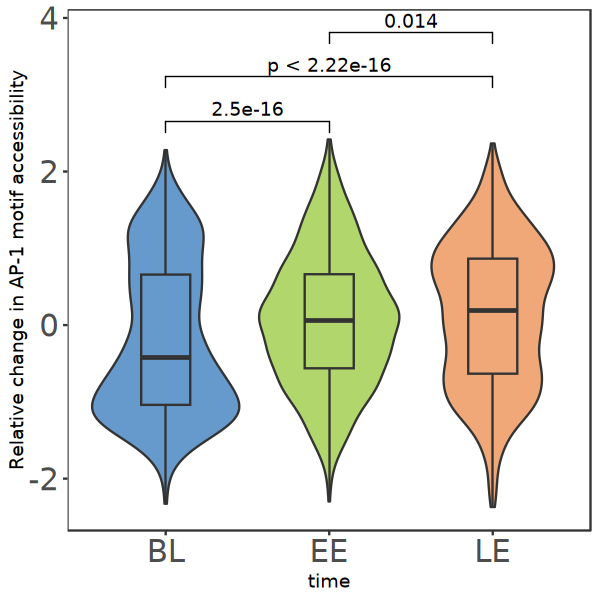

In [162]:
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure3/Relative_change_in_AP-1_motif_accessibility.pdf',width=5,height=5)
options(repr.plot.width=5, repr.plot.height=5)
plot <- ggplot(data=df.longer,aes(x=time,y=accessbility,fill=time)) + geom_violin(trim = T) +  
  geom_boxplot(width = 0.3, outlier.shape = NA) +  
  scale_fill_manual(values = c('#6699CC','#B1D66B','#F1A878'))+
  ylab('Expression level of Jun')+
  theme_bw()+
  theme(panel.grid = element_blank(),   
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text = element_text(face = "bold",size = 18)
  )+
  stat_compare_means(comparisons = list(c("EE", "BL"), c("LE", "BL"), c("LE", "EE")),
                     method = "wilcox.test",label = "p.format") + ylab('Relative change in AP-1 motif accessibility')
print(plot)
dev.off()
print(plot)
